**Deep Learning Framework for Leaf Disease Detection and Crop Damage Assessment using ResNet**

In [1]:
!pip install tensorflow opencv-python scikit-learn matplotlib efficientnet transformers segmentation_models_pytorch

In [2]:
#!conda create -n tf_env python=3.10
#!conda activate tf_env
#!conda install esri::tensorflow-addons

In [3]:
pip install tensorflow-addons==0.22.0

Note: you may need to restart the kernel to use updated packages.


In [4]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications import ResNet50, VGG16, EfficientNetB0, InceptionV3, DenseNet121
from keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D
from keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import cv2
from keras.applications import imagenet_utils

In [5]:
#import tensorflow as tf
#print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

In [6]:
# Load dataset
data_dir = 'C:\\Users\\HP\\OneDrive\\Desktop\\project\\Chapter4 Data\\Code\\PlantVillage'  # Path to the PlantVillage dataset
image_size = (224, 224)

In [7]:
un_healthy_images_list = ['Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Target_Spot',
                                     'Tomato_Late_blight', 'Tomato_Bacterial_spot','Tomato__Tomato_mosaic_virus', 'Tomato_Septoria_leaf_spot',
                                     'Tomato_Early_blight', 'Tomato_Leaf_Mold']

un_healthy_images_list

['Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Target_Spot',
 'Tomato_Late_blight',
 'Tomato_Bacterial_spot',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Early_blight',
 'Tomato_Leaf_Mold']

In [8]:

from PIL import Image

def is_image_file(filename):
    filename = filename.lower()
    return filename.endswith(".jpg") or filename.endswith(".jpeg") or filename.endswith(".png")

def load_dataset(data_dir, image_size, main_dir="C:\\Users\\HP\\OneDrive\\Desktop\\project\\Chapter4 Data\\Code\\PlantVillage"):
    image_data = []
    # labels = []

    for dir in data_dir:
      path = os.path.join(main_dir, dir)
      # print(path)

      imageNames = os.listdir(path)
      # print(imageNames)
      for image in imageNames:
        if not is_image_file(image):
              continue  # Skip non-image files

        image_path = os.path.join(path, image)
        imgs = Image.open(image_path)
        img = np.array(imgs)

        if img is None:
          print(f"Warning: Failed to load image {image}")
          continue  # Skip invalid images

        img = cv2.resize(img, image_size)
        image_data.append(img)
        # labels.append(label)
      # Append the corresponding label

    return np.array(image_data)



In [9]:
data_dir = un_healthy_images_list
image_size = (224, 224)  # Example size
unhealthy_images = load_dataset(data_dir, image_size)
print(unhealthy_images)  # Prints the labels corresponding to each image

[[[[154 144 143]
   [159 149 148]
   [152 142 141]
   ...
   [130 114 114]
   [118 102 102]
   [ 95  79  79]]

  [[160 150 149]
   [161 151 150]
   [148 138 137]
   ...
   [122 106 106]
   [118 102 102]
   [108  92  92]]

  [[155 145 144]
   [159 149 148]
   [149 139 138]
   ...
   [116 100 100]
   [108  92  92]
   [104  88  88]]

  ...

  [[152 141 139]
   [154 143 141]
   [151 140 138]
   ...
   [117  99  97]
   [113  95  93]
   [108  91  89]]

  [[143 132 130]
   [159 148 146]
   [139 128 126]
   ...
   [113  95  93]
   [112  94  92]
   [111  94  92]]

  [[150 139 137]
   [142 131 129]
   [141 130 128]
   ...
   [110  92  90]
   [110  92  90]
   [112  94  92]]]


 [[[146 140 144]
   [156 150 154]
   [163 157 161]
   ...
   [115 104 108]
   [106  95  99]
   [107  96 100]]

  [[139 132 137]
   [147 141 145]
   [148 142 146]
   ...
   [126 115 119]
   [126 115 119]
   [121 110 114]]

  [[148 142 146]
   [142 136 140]
   [147 141 145]
   ...
   [123 112 116]
   [115 104 108]
   [115 104

In [10]:
unhealthy_images.shape

(12744, 224, 224, 3)

In [11]:
np.random.seed(42)  # For reproducibility
indices = np.random.choice(len(unhealthy_images), 1000, replace=False)
unhealthy_images_resized = unhealthy_images[indices]
unhealthy_images_resized.shape

(1000, 224, 224, 3)

In [12]:
unhealthy_labels = np.ones(1000)


In [13]:
healthy_images_list = ["Tomato_healthy"]
healthy_images_list

['Tomato_healthy']

In [14]:
data_dir = healthy_images_list
# print(data_dir)
image_size = (224, 224)  # Example size
healthy_images = load_dataset(data_dir, image_size)
healthy_images

array([[[[132, 131, 137],
         [113, 112, 118],
         [ 99,  98, 104],
         ...,
         [116, 113, 124],
         [134, 131, 142],
         [120, 117, 128]],

        [[116, 115, 121],
         [119, 118, 123],
         [127, 126, 132],
         ...,
         [115, 112, 123],
         [112, 108, 120],
         [124, 121, 132]],

        [[139, 138, 144],
         [137, 136, 142],
         [130, 129, 135],
         ...,
         [111, 107, 118],
         [113, 110, 121],
         [124, 121, 132]],

        ...,

        [[ 69,  73,  77],
         [ 80,  82,  87],
         [ 67,  70,  75],
         ...,
         [ 83,  83,  93],
         [ 74,  74,  84],
         [ 78,  78,  88]],

        [[ 68,  71,  76],
         [ 66,  69,  74],
         [ 58,  61,  66],
         ...,
         [ 76,  76,  86],
         [ 78,  78,  88],
         [ 90,  90, 100]],

        [[ 70,  73,  78],
         [ 56,  59,  64],
         [ 56,  59,  64],
         ...,
         [ 75,  75,  85],
        

In [15]:
healthy_images.shape

(1591, 224, 224, 3)

In [16]:
healthy_labels = np.zeros(1591)
healthy_labels

array([0., 0., 0., ..., 0., 0., 0.])

In [17]:
images = np.concatenate((healthy_images, unhealthy_images_resized), axis=0)
labels = np.concatenate((healthy_labels, unhealthy_labels), axis=0)
print(images.shape)
print(labels.shape)

(2591, 224, 224, 3)
(2591,)


In [18]:
from sklearn.model_selection import train_test_split

In [19]:
images = images / 255.0
X_train, X_val, y_train, y_val = train_test_split(images, labels, test_size=0.2, random_state=42)

# RESNET

In [20]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split


In [21]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

# Load ResNet50 model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

In [22]:
# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Freeze the layers of ResNet50
for layer in base_model.layers:
    layer.trainable = False

In [23]:
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [24]:
# Train the model
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=40
)

C:\Users\HP\anaconda31\envs\tf_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.5329 - loss: 3.2198
Epoch 2/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.6124 - loss: 0.6971
Epoch 3/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.6122 - loss: 0.6819
Epoch 4/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.6215 - loss: 0.7126
Epoch 5/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.6309 - loss: 0.6690
Epoch 6/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.6195 - loss: 0.6691
Epoch 7/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.6056 - loss: 0.6719
Epoch 8/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.6246 - loss: 0.6645
Epoch 9/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.6158 - loss: 0.6669
Epoch 10/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.6022 - loss: 0.6721
Epoch 11/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.6266 - loss: 0.6618
Epoch 12/40
65/65 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.6064 

In [25]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [26]:
import pandas as pd
# Convert the history dictionary to a DataFrame
history_df = pd.DataFrame(history.history)
# Display the DataFrame
history_df.index += 1  # To set the index starting from 1 (for epochs)
print(history_df)

    accuracy      loss
1   0.537645  1.636934
2   0.615348  0.690908
3   0.615348  0.680083
4   0.610521  0.718991
5   0.615348  0.672103
6   0.615348  0.669872
7   0.615348  0.668460
8   0.615348  0.667587
9   0.615348  0.667046
10  0.615348  0.666729
11  0.615348  0.666598
12  0.615348  0.666472
13  0.615348  0.666413
14  0.615348  0.666333
15  0.615348  0.666337
16  0.615348  0.666345
17  0.615348  0.666343
18  0.615348  0.666349
19  0.615348  0.666340
20  0.615348  0.666329
21  0.615348  0.666324
22  0.615348  0.666332
23  0.615348  0.666373
24  0.615348  0.666334
25  0.615348  0.666343
26  0.615348  0.666364
27  0.615348  0.666346
28  0.615348  0.666330
29  0.615348  0.666349
30  0.615348  0.666323
31  0.615348  0.666368
32  0.615348  0.666356
33  0.615348  0.666396
34  0.615348  0.666345
35  0.615348  0.666373
36  0.615348  0.666331
37  0.615348  0.666378
38  0.615348  0.666354
39  0.615348  0.666336
40  0.615348  0.666395


In [27]:
history_df.to_csv('training_history1.csv', index_label='Epoch')

In [28]:
# Evaluate the model on the validation set
val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=1)
print(f"Test Accuracy: {val_accuracy}")

17/17 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.6212 - loss: 0.6636
Test Accuracy: 0.6088631749153137


In [29]:
from sklearn.metrics import classification_report

# Generate classification report for test set
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_val, y_pred_classes))

17/17 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step
              precision    recall  f1-score   support

         0.0       0.61      1.00      0.76       316
         1.0       0.00      0.00      0.00       203

    accuracy                           0.61       519
   macro avg       0.30      0.50      0.38       519
weighted avg       0.37      0.61      0.46       519



C:\Users\HP\anaconda31\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda31\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\anaconda31\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [53]:
import matplotlib.pyplot as plt
import pandas as pd

In [55]:
history_df = pd.DataFrame(history_df)
history_df.index += 1  # Set the index to start from 1 to represent epochs

# Plotting training & validation accuracy values
plt.figure(figsize=(14, 6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

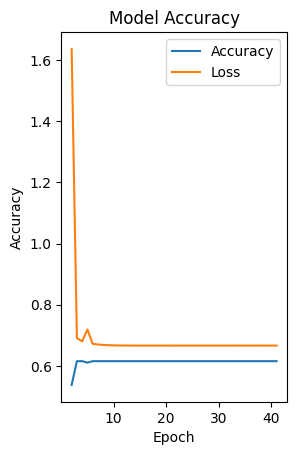

In [58]:
plt.subplot(1, 2, 1)
plt.plot(history_df.index, history_df['accuracy'], label='Accuracy')
plt.plot(history_df.index, history_df['loss'], label='Loss')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()